In [ ]:
# 🏥 Hospital Recovery Analysis
### Exploratory Data Analysis | Statistical Analysis | Machine Learning

**Dataset:** `hospital_patient_treatment_dataset.csv`  
**Rows:** 200 patients | **Features:** 9 columns  
**Target:** `Recovery Score` (continuous, 40–100)


## 1. Setup & Data Loading

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, ttest_ind, f_oneway, chi2_contingency, pearsonr, spearmanr
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

df = pd.read_csv('hospital_patient_treatment_dataset[1].csv')
print("Shape:", df.shape)
df.head()


Shape: (200, 9)


,Patient ID,Department,Treatment Type,Doctor Name,Gender,Age,Treatment Cost,Hospital Stay (Days),Recovery Score
0,P1001,Gastroenterology,Therapy,Dr. L. Khan,Female,12,68632.97,21,82
1,P1002,Pediatrics,Medication,Dr. M. Patel,Male,52,10231.42,20,42
2,P1003,Pediatrics,Therapy,Dr. L. Khan,Male,79,10160.24,2,72
3,P1004,Pediatrics,Therapy,Dr. L. Khan,Female,23,103508.96,20,50
4,P1005,Orthopedics,Medication,Dr. T. Mehta,Female,7,143427.52,6,43


# Data Overview

In [6]:
# Categorical columns
cat_cols = ['Department', 'Treatment Type', 'Gender', 'Doctor Name']
for c in cat_cols:
    print(f"\n{c} ({df[c].nunique()} unique):")
    print(df[c].value_counts().to_string())


Department (6 unique):
Department
Gastroenterology    41
Pediatrics          38
Orthopedics         38
Oncology            31
Neurology           28
Cardiology          24

Treatment Type (4 unique):
Treatment Type
Medication     55
Therapy        50
Surgery        48
Observation    47

Gender (3 unique):
Gender
Male      81
Other     62
Female    57

Doctor Name (5 unique):
Doctor Name
Dr. L. Khan      46
Dr. R. Singh     45
Dr. M. Patel     41
Dr. T. Mehta     38
Dr. A. Sharma    30


# Exploratory Data Analysis

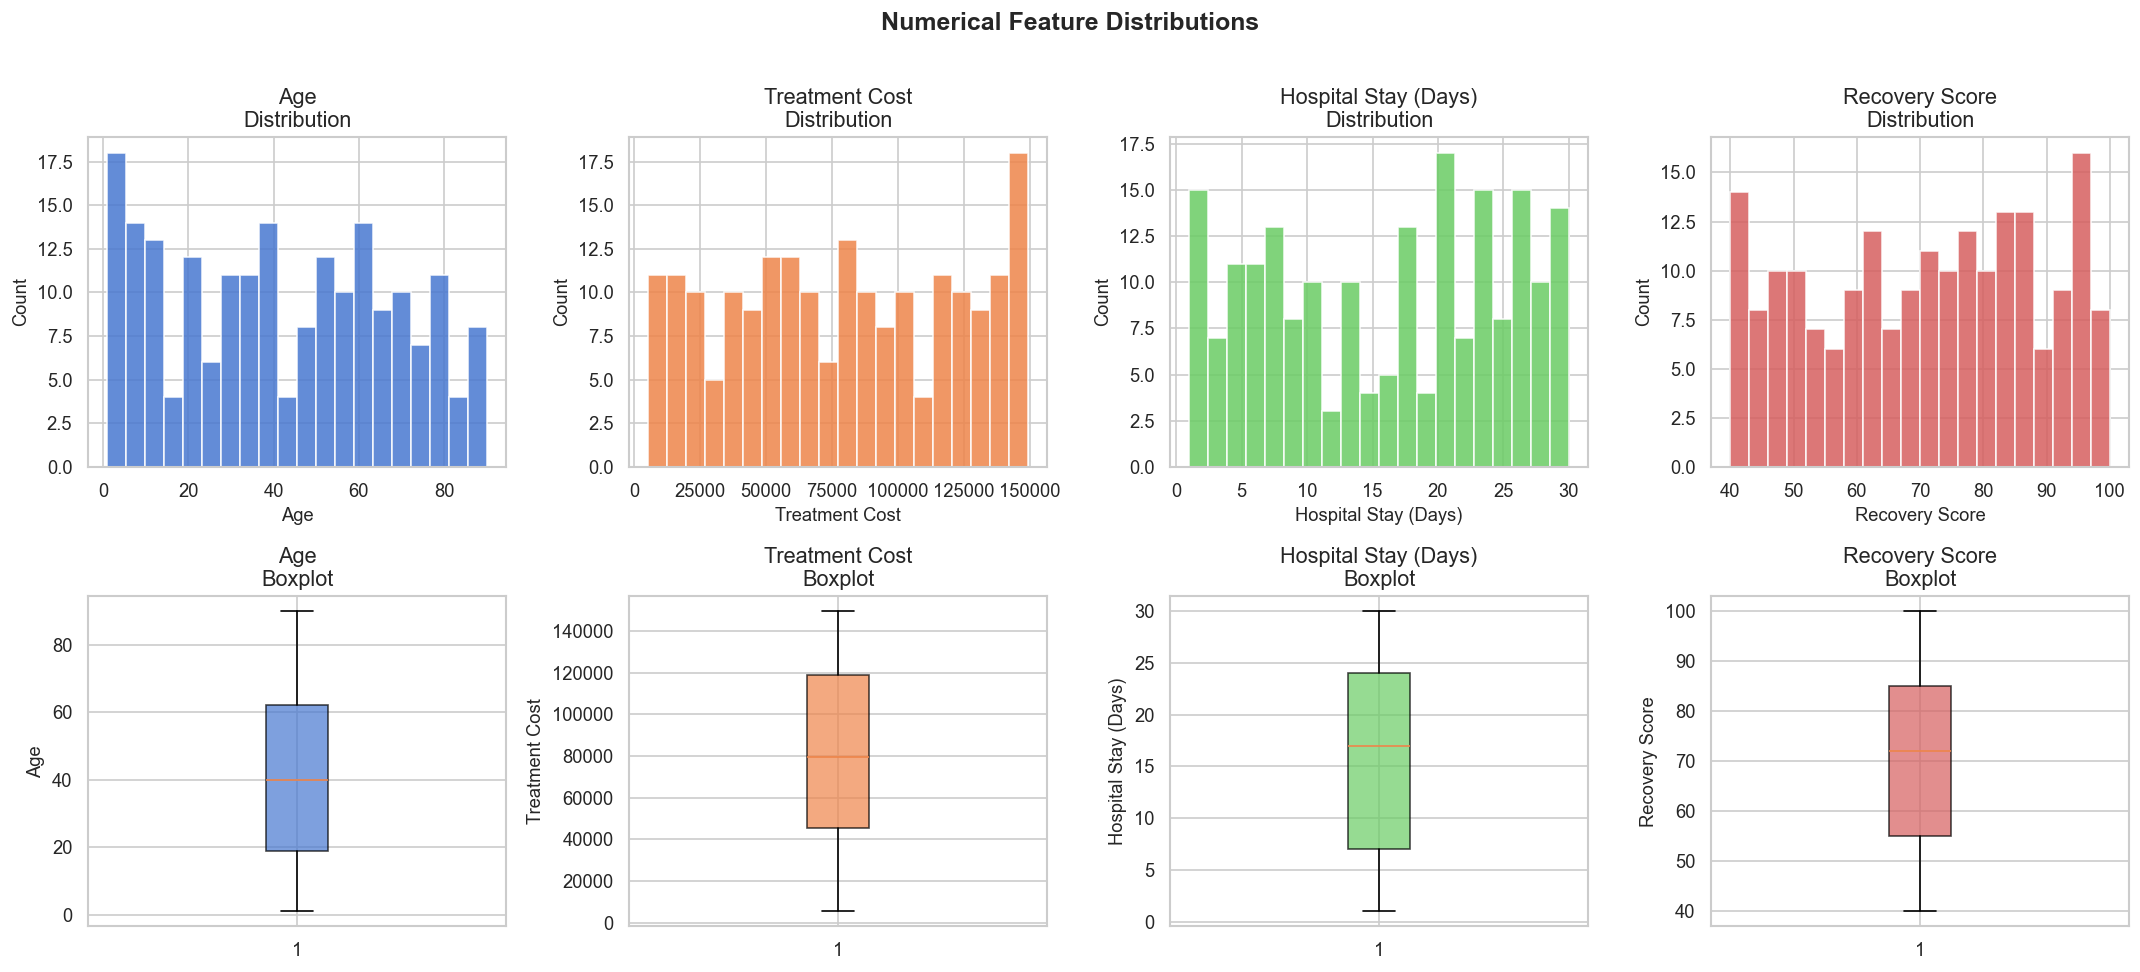

In [7]:
num_cols = ['Age', 'Treatment Cost', 'Hospital Stay (Days)', 'Recovery Score']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(df[col], bins=20, color=sns.color_palette('muted')[i], edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'{col}\nDistribution')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')

    # Boxplot
    axes[1, i].boxplot(df[col], patch_artist=True,
    boxprops=dict(facecolor=sns.color_palette('muted')[i], alpha=0.7))
    axes[1, i].set_title(f'{col}\nBoxplot')
    axes[1, i].set_ylabel(col)

plt.suptitle('Numerical Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

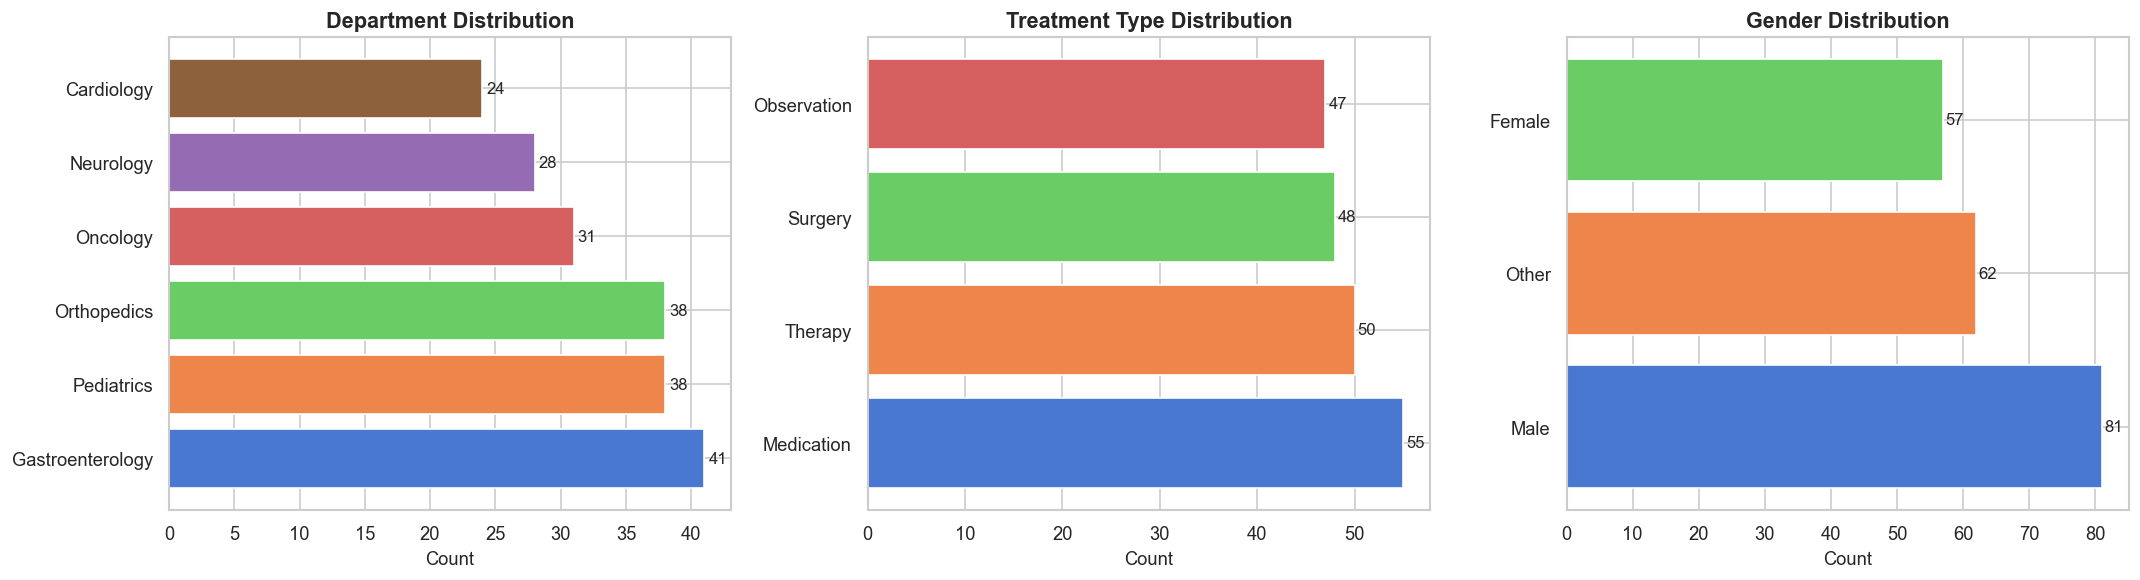

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['Department', 'Treatment Type', 'Gender']):
    counts = df[col].value_counts()
    bars = axes[i].barh(counts.index, counts.values, color=sns.color_palette('muted'))
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_xlabel('Count')
    for bar, val in zip(bars, counts.values):
        axes[i].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                     str(val), va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Recovery Score by category

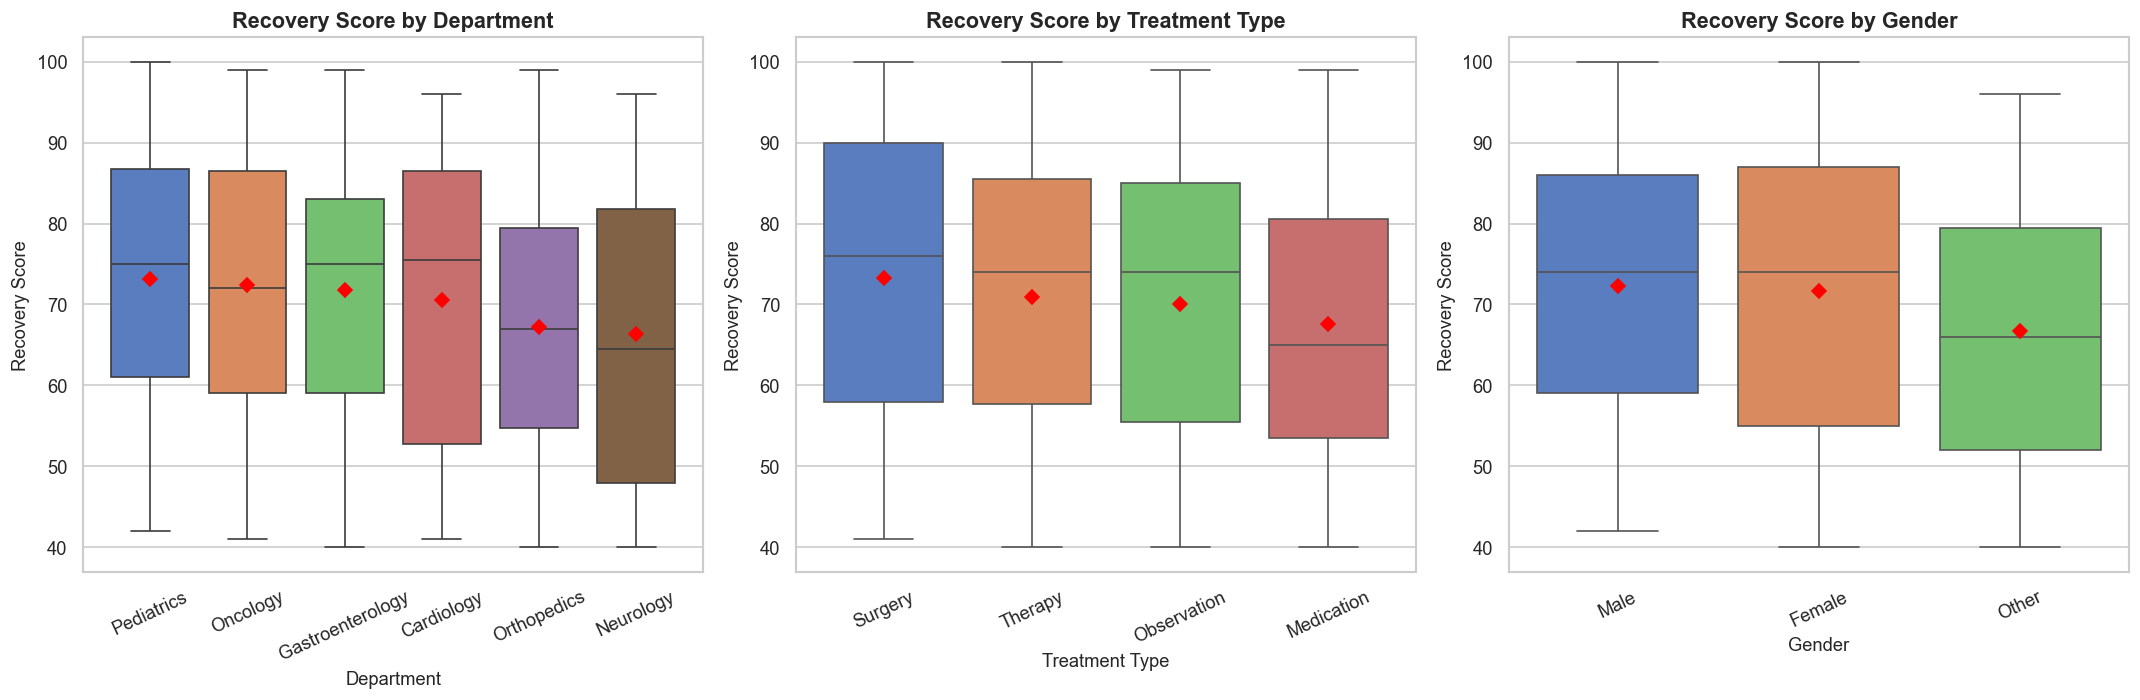

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(['Department', 'Treatment Type', 'Gender']):
    group_means = df.groupby(col)['Recovery Score'].mean().sort_values(ascending=False)
    palette = sns.color_palette('muted', len(group_means))
    
    sns.boxplot(data=df, x=col, y='Recovery Score', ax=axes[i], palette='muted',
                order=group_means.index)
    axes[i].set_title(f'Recovery Score by {col}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=25)
    
    # Overlay mean points
    for j, dept in enumerate(group_means.index):
        mean_val = group_means[dept]
        axes[i].plot(j, mean_val, 'D', color='red', markersize=6, zorder=5)

plt.tight_layout()
plt.show()

# Correlation Heatmap

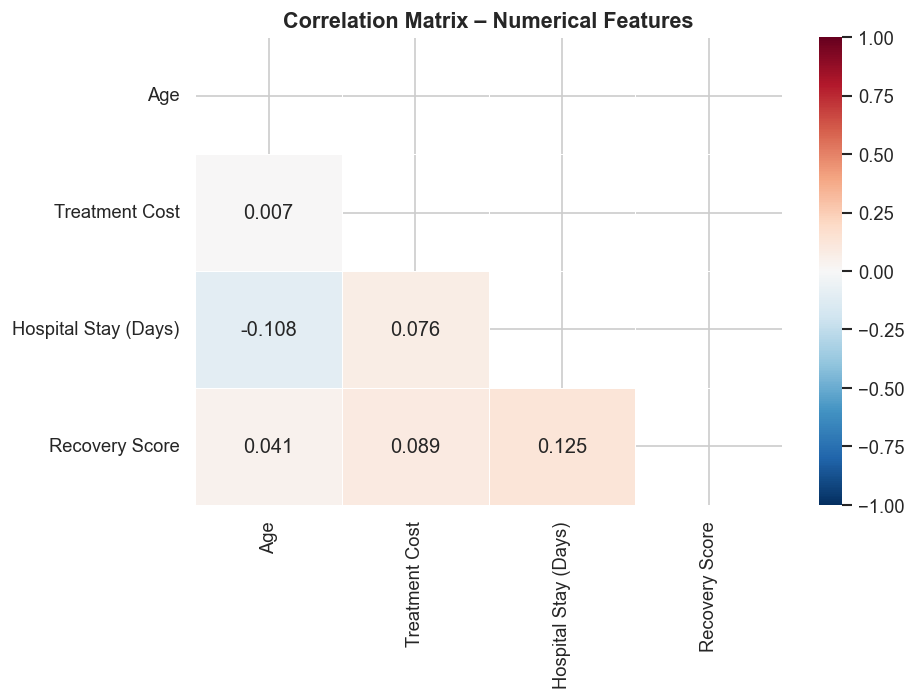


Correlation with Recovery Score:
Hospital Stay (Days)    0.125254
Treatment Cost          0.088918
Age                     0.040800
Name: Recovery Score, dtype: float64


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 12})
ax.set_title('Correlation Matrix – Numerical Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\nCorrelation with Recovery Score:")
print(corr['Recovery Score'].drop('Recovery Score').sort_values(ascending=False))

# Scatter Plots vs Recovery score

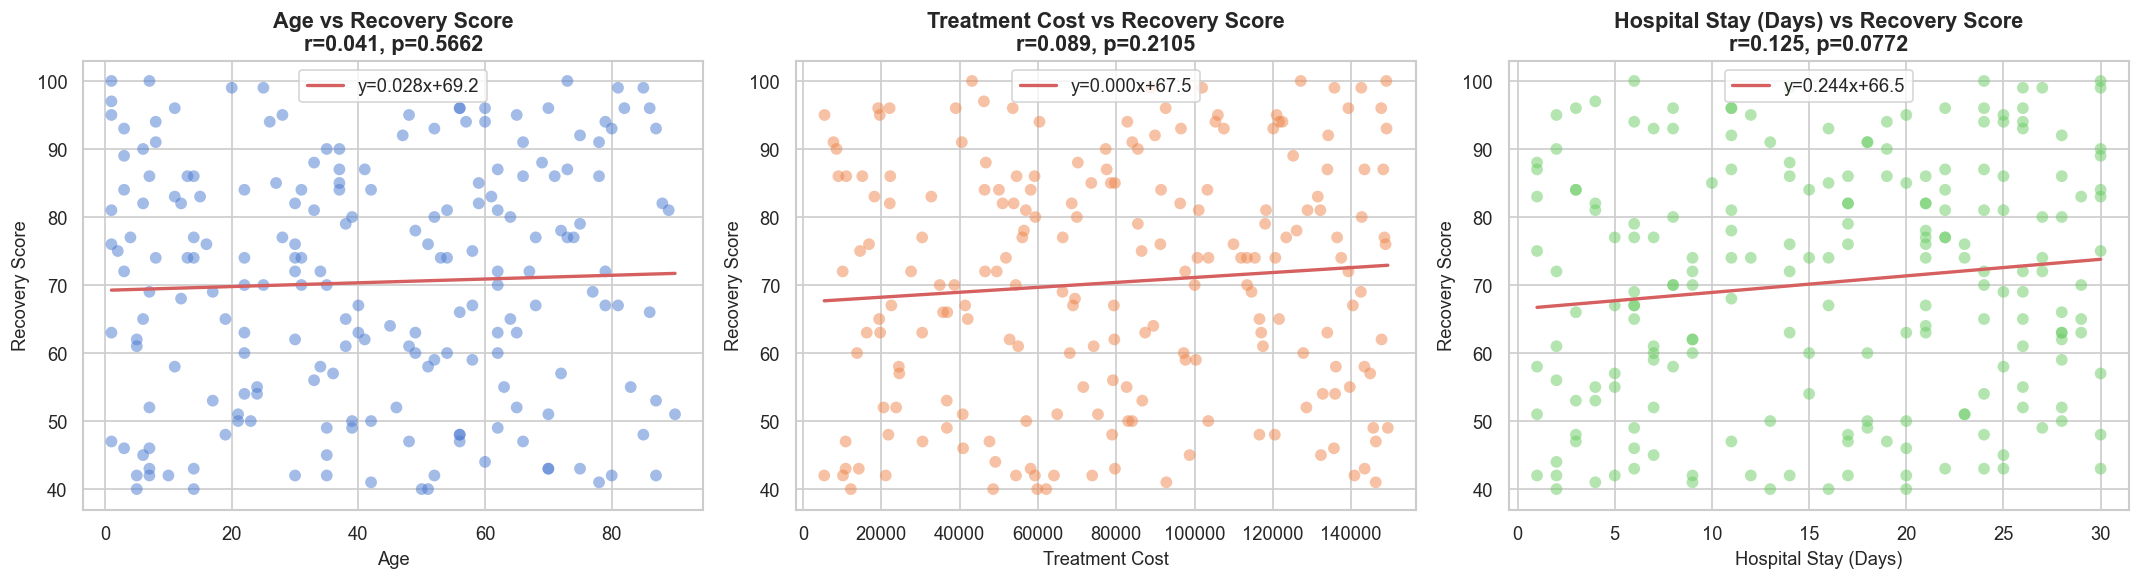

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
feat_cols = ['Age', 'Treatment Cost', 'Hospital Stay (Days)']
colors = sns.color_palette('muted', 3)

for i, col in enumerate(feat_cols):
    axes[i].scatter(df[col], df['Recovery Score'], alpha=0.5, color=colors[i], edgecolors='none', s=50)
    
    # Regression line
    m, b = np.polyfit(df[col], df['Recovery Score'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m*x_line + b, 'r-', linewidth=2, label=f'y={m:.3f}x+{b:.1f}')
    
    r, p = pearsonr(df[col], df['Recovery Score'])
    axes[i].set_title(f'{col} vs Recovery Score\nr={r:.3f}, p={p:.4f}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Recovery Score')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Age Group Analysis

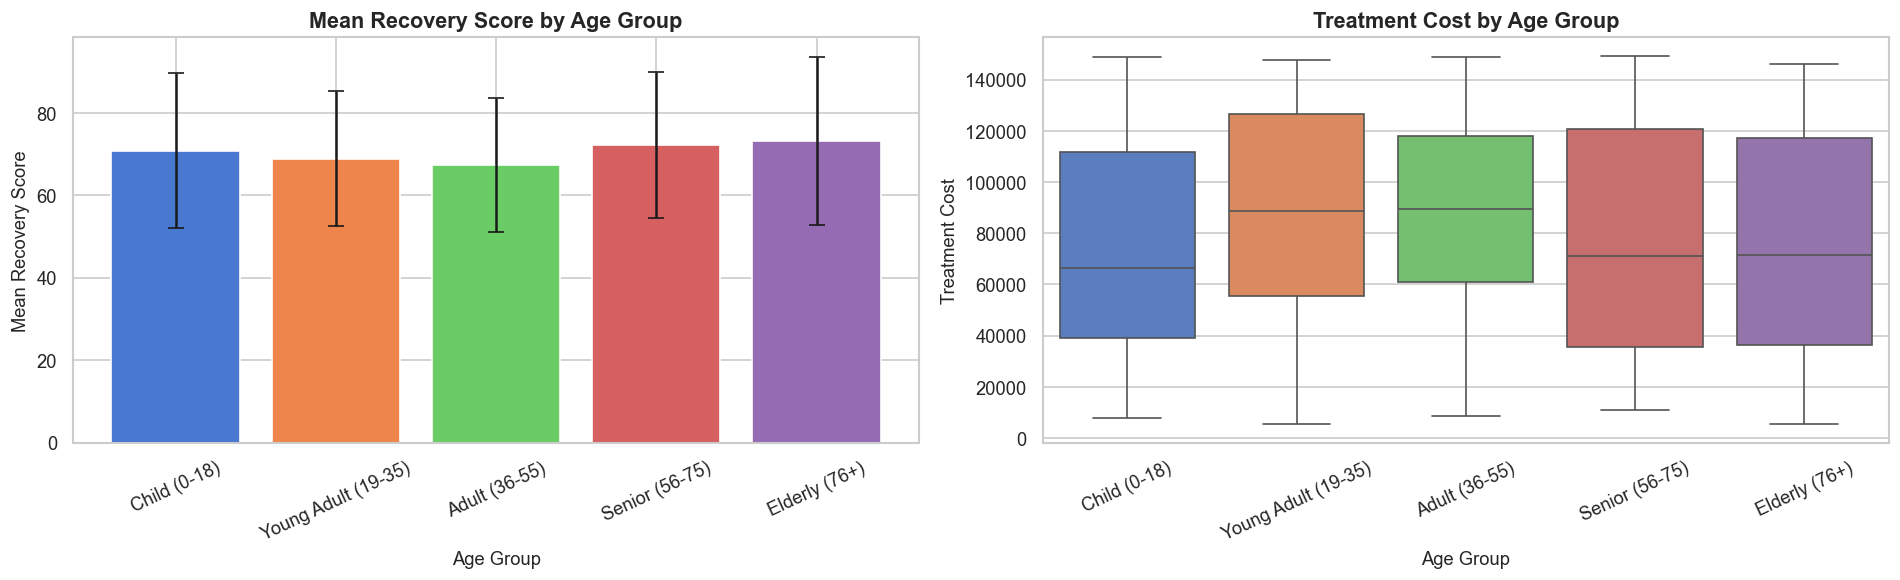


Age Group Summary:
                     Recovery Score  Treatment Cost  Hospital Stay (Days)
Age Group                                                                
Child (0-18)                  70.80        72477.39                 16.55
Young Adult (19-35)           68.82        88494.06                 18.31
Adult (36-55)                 67.44        86704.90                 15.18
Senior (56-75)                72.18        76387.66                 14.96
Elderly (76+)                 73.17        75485.57                 14.70


In [12]:
df['Age Group'] = pd.cut(df['Age'],
    bins=[0, 18, 35, 55, 75, 100],
    labels=['Child (0-18)', 'Young Adult (19-35)', 'Adult (36-55)', 'Senior (56-75)', 'Elderly (76+)'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mean recovery per age group
age_stats = df.groupby('Age Group')['Recovery Score'].agg(['mean', 'std', 'count'])
axes[0].bar(age_stats.index, age_stats['mean'], 
             yerr=age_stats['std'], capsize=5,
             color=sns.color_palette('muted', 5), edgecolor='white')
axes[0].set_title('Mean Recovery Score by Age Group', fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Mean Recovery Score')
axes[0].tick_params(axis='x', rotation=25)

# Treatment cost per age group
sns.boxplot(data=df, x='Age Group', y='Treatment Cost', ax=axes[1], palette='muted')
axes[1].set_title('Treatment Cost by Age Group', fontweight='bold')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

print("\nAge Group Summary:")
print(df.groupby('Age Group')[['Recovery Score', 'Treatment Cost', 'Hospital Stay (Days)']].mean().round(2))

# HeatMap: Department,Treatment,Recovery

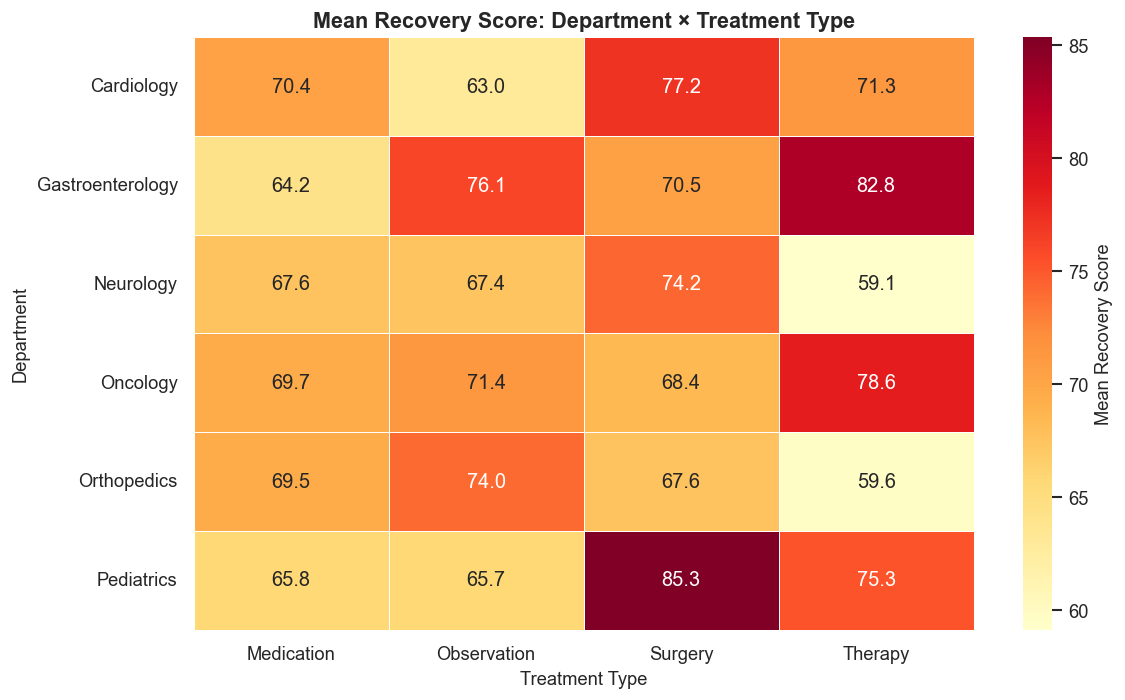

In [13]:
pivot = df.pivot_table(values='Recovery Score', index='Department', columns='Treatment Type', aggfunc='mean')
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Mean Recovery Score'})
ax.set_title('Mean Recovery Score: Department × Treatment Type', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Statistical Analysis

# Normality Analysis

In [16]:
print("Shapiro-Wilk Normality Test (H0: data is normally distributed)")
print("="*60)
for col in num_cols:
    stat, p = shapiro(df[col])
    result = "✅ Normal" if p > 0.05 else "❌ Non-normal"
    print(f"{col:25s}  W={stat:.4f}  p={p:.4f}  → {result}")

Shapiro-Wilk Normality Test (H0: data is normally distributed)
Age                        W=0.9501  p=0.0000  → ❌ Non-normal
Treatment Cost             W=0.9473  p=0.0000  → ❌ Non-normal
Hospital Stay (Days)       W=0.9335  p=0.0000  → ❌ Non-normal
Recovery Score             W=0.9509  p=0.0000  → ❌ Non-normal


# T-Test: Recovery Score by Gender (Male vs Female)

Male    → Mean: 72.28, Std: 17.71, n=81
Female  → Mean: 71.61, Std: 18.31, n=57

Levene's test: p=0.6168 → Equal variances
Independent T-test: t=0.2158, p=0.8295
Result: No significant difference ❌ (α=0.05)


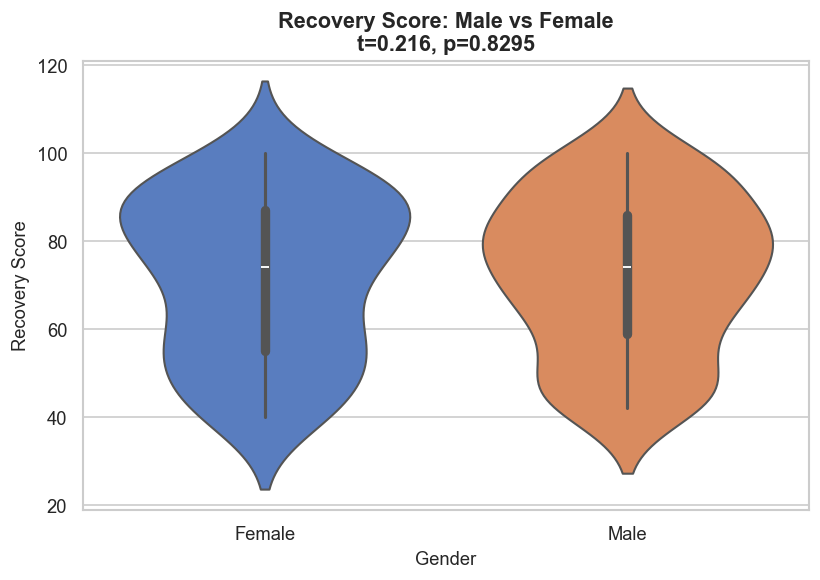

In [14]:
male_scores = df[df['Gender'] == 'Male']['Recovery Score']
female_scores = df[df['Gender'] == 'Female']['Recovery Score']

# Levene's test for equal variances
from scipy.stats import levene
lev_stat, lev_p = levene(male_scores, female_scores)
equal_var = lev_p > 0.05

t_stat, p_val = ttest_ind(male_scores, female_scores, equal_var=equal_var)

print(f"Male    → Mean: {male_scores.mean():.2f}, Std: {male_scores.std():.2f}, n={len(male_scores)}")
print(f"Female  → Mean: {female_scores.mean():.2f}, Std: {female_scores.std():.2f}, n={len(female_scores)}")
print(f"\nLevene's test: p={lev_p:.4f} → {'Equal' if equal_var else 'Unequal'} variances")
print(f"Independent T-test: t={t_stat:.4f}, p={p_val:.4f}")
print(f"Result: {'Significant difference ✅' if p_val < 0.05 else 'No significant difference ❌'} (α=0.05)")

# Visualize
fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(data=df[df['Gender'].isin(['Male', 'Female'])],
               x='Gender', y='Recovery Score', palette='muted', ax=ax, inner='box')
ax.set_title(f'Recovery Score: Male vs Female\nt={t_stat:.3f}, p={p_val:.4f}', fontweight='bold')
plt.tight_layout()
plt.show()

### One-Way ANOVA: Recovery Score across Departments

In [17]:
groups = [group['Recovery Score'].values for _, group in df.groupby('Department')]
f_stat, p_val = f_oneway(*groups)

print(f"One-Way ANOVA: F={f_stat:.4f}, p={p_val:.4f}")
print(f"Result: {'Significant difference between departments ✅' if p_val < 0.05 else 'No significant difference ❌'}")
print()

dept_stats = df.groupby('Department')['Recovery Score'].agg(['mean', 'std', 'count'])
print(dept_stats.sort_values('mean', ascending=False).round(2))

# Post-hoc Tukey HSD if significant
if p_val < 0.05:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    tukey = pairwise_tukeyhsd(df['Recovery Score'], df['Department'], alpha=0.05)
    print("\nTukey HSD Post-hoc Test:")
    print(tukey.summary())

One-Way ANOVA: F=0.8332, p=0.5276
Result: No significant difference ❌

                   mean    std  count
Department                           
Pediatrics        73.13  17.73     38
Oncology          72.42  17.82     31
Gastroenterology  71.80  16.90     41
Cardiology        70.50  19.57     24
Orthopedics       67.26  16.44     38
Neurology         66.39  19.09     28


### One-Way ANOVA: Recovery Score across Treatment Types

In [19]:
groups2 = [g['Recovery Score'].values for _, g in df.groupby('Treatment Type')]
f2, p2 = f_oneway(*groups2)
print(f"One-Way ANOVA (Treatment Type): F={f2:.4f}, p={p2:.4f}")
print(f"Result: {'Significant ✅' if p2 < 0.05 else 'Not significant ❌'}")
print()
print(df.groupby('Treatment Type')['Recovery Score'].agg(['mean','std','count']).sort_values('mean', ascending=False).round(2))

One-Way ANOVA (Treatment Type): F=0.9128, p=0.4358
Result: Not significant ❌

                 mean    std  count
Treatment Type                     
Surgery         73.29  17.58     48
Therapy         70.98  17.38     50
Observation     70.02  18.28     47
Medication      67.58  17.73     55


### 4.5 Pearson & Spearman Correlations with Recovery Score

In [20]:
print(f"{'Feature':<25} {'Pearson r':>10} {'Pearson p':>10} {'Spearman r':>12} {'Spearman p':>12}")
print("-"*70)
for col in ['Age', 'Treatment Cost', 'Hospital Stay (Days)']:
    pr, pp = pearsonr(df[col], df['Recovery Score'])
    sr, sp = spearmanr(df[col], df['Recovery Score'])
    sig_p = '✅' if pp < 0.05 else '  '
    sig_s = '✅' if sp < 0.05 else '  '
    print(f"{col:<25} {pr:>9.4f}{sig_p} {pp:>10.4f} {sr:>11.4f}{sig_s} {sp:>11.4f}")

Feature                    Pearson r  Pearson p   Spearman r   Spearman p
----------------------------------------------------------------------
Age                          0.0408       0.5662      0.0432        0.5436
Treatment Cost               0.0889       0.2105      0.0819        0.2487
Hospital Stay (Days)         0.1253       0.0772      0.1242        0.0797


### Chi-Square: Department vs Treatment Type

In [21]:
ct = pd.crosstab(df['Department'], df['Treatment Type'])
chi2, p_chi, dof, expected = chi2_contingency(ct)
print(f"Chi-Square Test: χ²={chi2:.4f}, df={dof}, p={p_chi:.4f}")
print(f"Result: {'Association exists ✅' if p_chi < 0.05 else 'No association ❌'}")
print()
print("Observed Crosstab:")
print(ct)

Chi-Square Test: χ²=9.4434, df=15, p=0.8532
Result: No association ❌

Observed Crosstab:
Treatment Type    Medication  Observation  Surgery  Therapy
Department                                                 
Cardiology                 8            5        5        6
Gastroenterology          13           11       11        6
Neurology                  8            9        4        7
Oncology                   6            5       10       10
Orthopedics               12            7        9       10
Pediatrics                 8           10        9       11


# Descriptive Statistic Summary

In [ ]:
summary = df[num_cols].agg(['mean', 'median', 'std', 'min', 'max',
                             lambda x: x.quantile(0.25),
                             lambda x: x.quantile(0.75),
                             lambda x: x.skew(),
                             lambda x: x.kurtosis()])
summary.index = ['Mean', 'Median', 'Std', 'Min', 'Max', 'Q1', 'Q3', 'Skewness', 'Kurtosis']
print(summary.round(3))

# Machine Learning

### Feature Engineering & Preprocessing

In [29]:
# Encode categoricals
df_ml = df.copy()
le = LabelEncoder()
for col in ['Department', 'Treatment Type', 'Gender']:
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col])

# Features
feature_cols = ['Age', 'Treatment Cost', 'Hospital Stay (Days)',
                'Department_enc', 'Treatment Type_enc', 'Gender_enc']
X = df_ml[feature_cols]
y = df_ml['Recovery Score']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print("Features:", feature_cols)

Train size: 160 | Test size: 40
Features: ['Age', 'Treatment Cost', 'Hospital Stay (Days)', 'Department_enc', 'Treatment Type_enc', 'Gender_enc']


# Train Multiple Models

In [30]:
models = {
    'Linear Regression':    LinearRegression(),
    'Ridge Regression':     Ridge(alpha=1.0),
    'Lasso Regression':     Lasso(alpha=1.0),
    'Decision Tree':        DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = []
for name, model in models.items():
    # Use scaled data for linear models, raw for tree-based
    use_scaled = 'Regression' in name
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test
    
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    cv   = cross_val_score(model, Xtr, y_train, cv=5, scoring='r2').mean()
    
    results.append({'Model': name, 'R²': r2, 'RMSE': rmse, 'MAE': mae, 'CV R²': cv})

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print(results_df.to_string(index=False, float_format='{:.4f}'.format))

            Model      R²    RMSE     MAE   CV R²
Linear Regression -0.0305 19.6864 17.3740 -0.1068
 Ridge Regression -0.0306 19.6877 17.3759 -0.1056
 Lasso Regression -0.0643 20.0070 17.6795 -0.0466
    Random Forest -0.1413 20.7181 18.4153 -0.3252
    Decision Tree -0.1453 20.7544 17.8381 -0.6384
Gradient Boosting -0.3901 22.8652 20.1381 -0.4579


# Model Comparison Visulaization

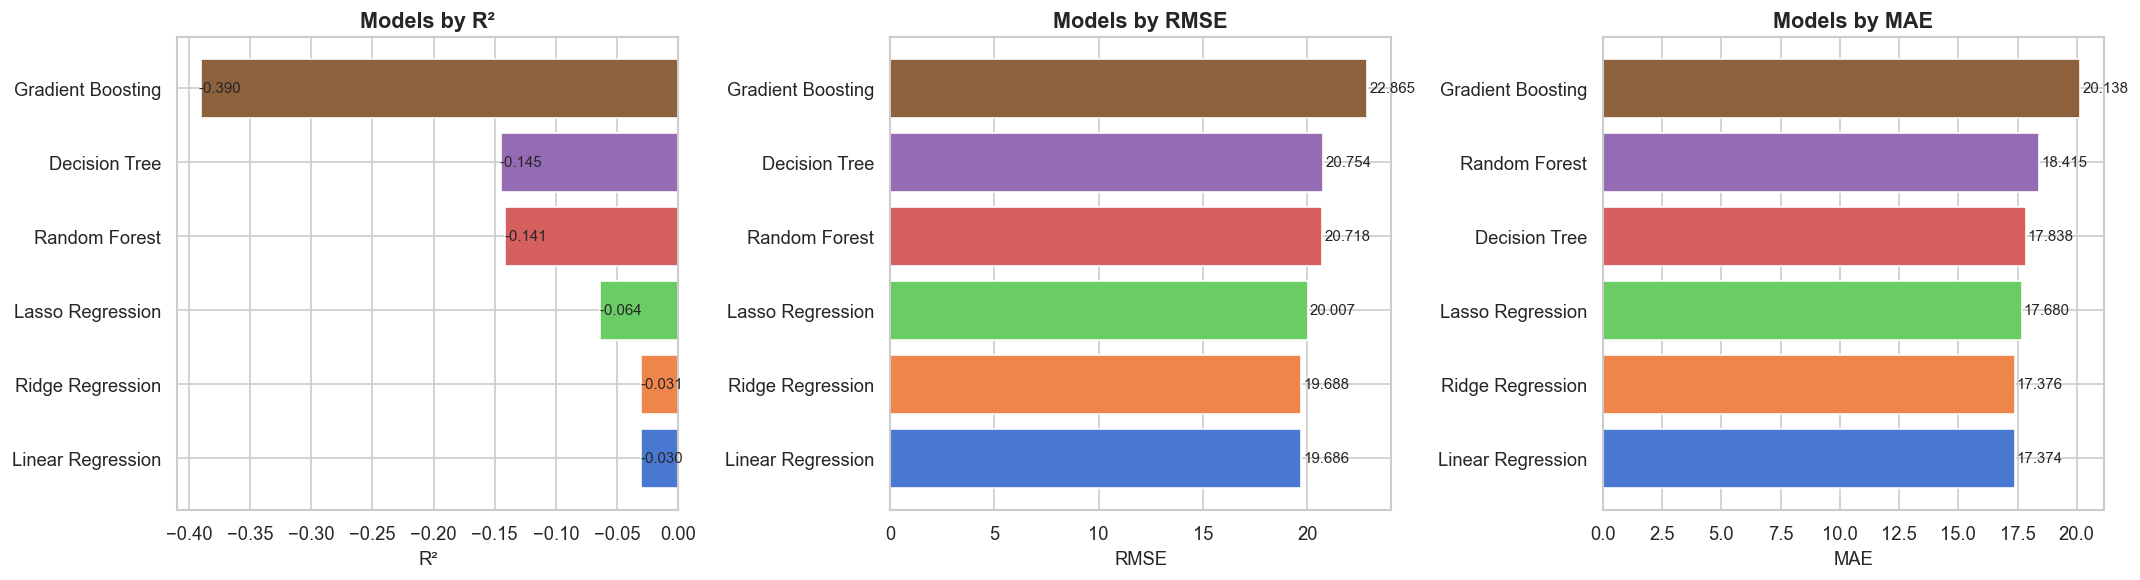

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['R²', 'RMSE', 'MAE']
colors = sns.color_palette('muted', len(results_df))

for i, metric in enumerate(metrics):
    order = results_df.sort_values(metric, ascending=(metric != 'R²'))
    bars = axes[i].barh(order['Model'], order[metric], color=colors)
    axes[i].set_title(f'Models by {metric}', fontweight='bold')
    axes[i].set_xlabel(metric)
    for bar, val in zip(bars, order[metric]):
        axes[i].text(val * 1.005, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Random Forest

In [32]:
param_grid = {
    'n_estimators':  [50, 100, 200],
    'max_depth':     [3, 5, None],
    'min_samples_split': [2, 5],
}
gs = GridSearchCV(RandomForestRegressor(random_state=42), param_grid,
                  cv=5, scoring='r2', n_jobs=-1)
gs.fit(X_train, y_train)

best_rf = gs.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("Best Params:", gs.best_params_)
print(f"Best CV R²:  {gs.best_score_:.4f}")
print(f"Test R²:     {r2_score(y_test, y_pred_best):.4f}")
print(f"Test RMSE:   {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}")
print(f"Test MAE:    {mean_absolute_error(y_test, y_pred_best):.4f}")

Best Params: {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R²:  -0.1316
Test R²:     -0.1260
Test RMSE:   20.5784
Test MAE:    18.3165


In [ ]:
# Actual VS Predicted

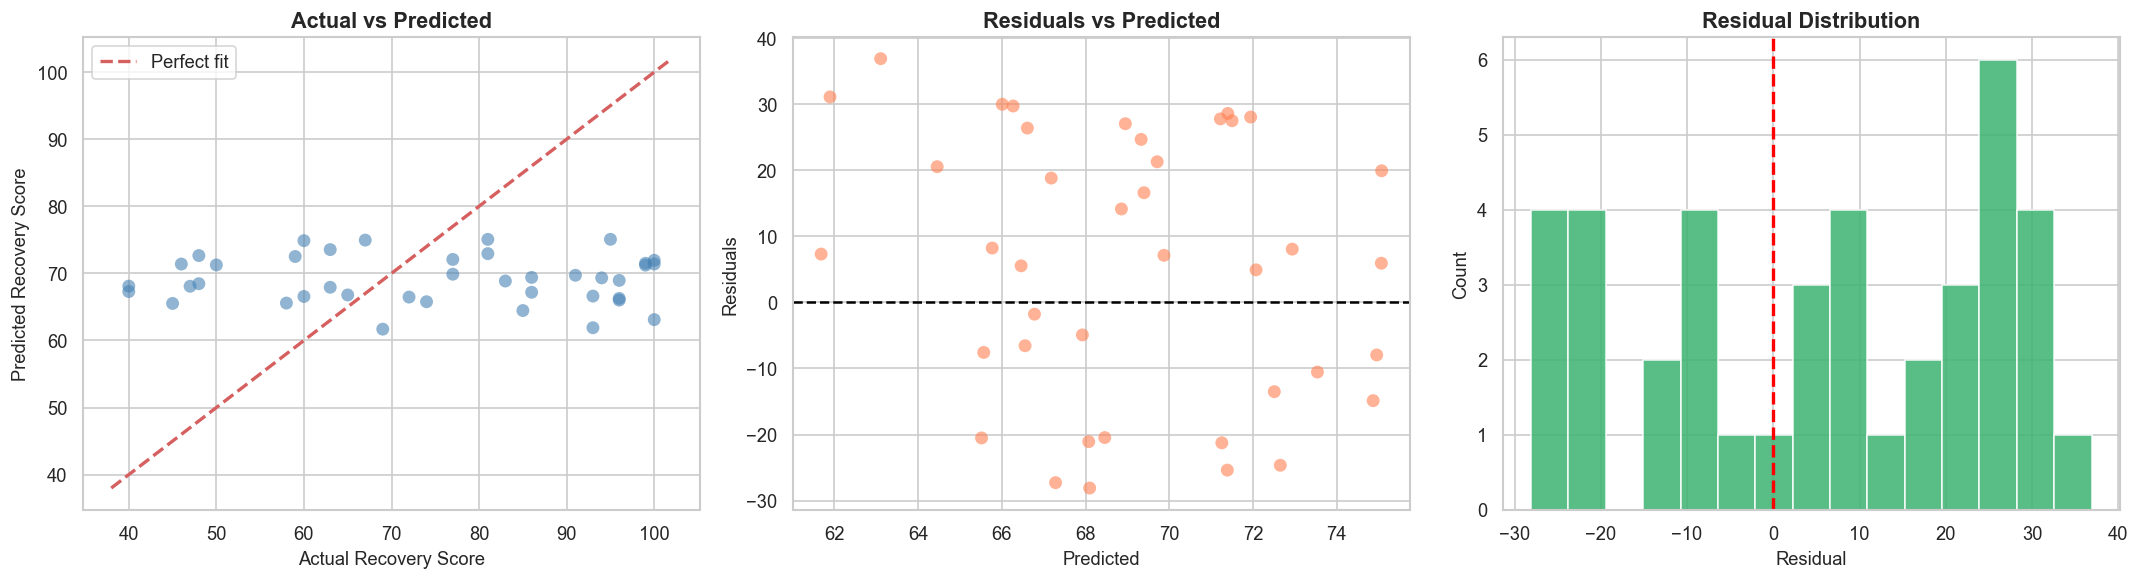

In [33]:
y_pred_best = best_rf.predict(X_test)
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.6, color='steelblue', edgecolors='none', s=60)
lims = [min(y_test.min(), y_pred_best.min()) - 2, max(y_test.max(), y_pred_best.max()) + 2]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect fit')
axes[0].set_xlabel('Actual Recovery Score')
axes[0].set_ylabel('Predicted Recovery Score')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].legend()

# Residuals vs Predicted
axes[1].scatter(y_pred_best, residuals, alpha=0.6, color='coral', edgecolors='none', s=60)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted', fontweight='bold')

# Residual distribution
axes[2].hist(residuals, bins=15, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[2].axvline(0, color='red', linewidth=2, linestyle='--')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

# Important Features

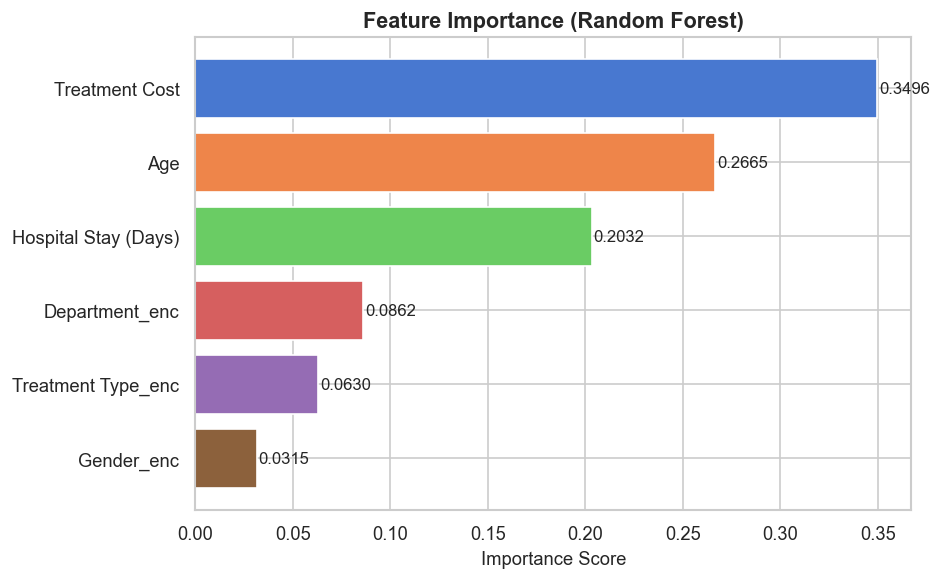


Feature Importance Ranking:
  Treatment Cost                 0.3496  (35.0%)
  Age                            0.2665  (26.6%)
  Hospital Stay (Days)           0.2032  (20.3%)
  Department_enc                 0.0862  (8.6%)
  Treatment Type_enc             0.0630  (6.3%)
  Gender_enc                     0.0315  (3.1%)


In [34]:
importances = best_rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette('muted', len(feat_imp))
bars = ax.barh(feat_imp.index[::-1], feat_imp.values[::-1], color=colors[::-1])
ax.set_title('Feature Importance (Random Forest)', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, feat_imp.values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
for f, v in feat_imp.items():
    print(f"  {f:<30} {v:.4f}  ({v*100:.1f}%)")

In [ ]:
## 6. Summary & Key Findings

### 📊 EDA Findings
- Dataset is **clean** — no missing values across all 200 patient records.
- **Recovery Score** ranges 40–100 (mean ≈ 70), roughly symmetric distribution.
- **Treatment Cost** is highly variable (std ≈ 43k), suggesting major cost spread across departments.
- Gastroenterology has the highest patient count; Cardiology the fewest.

### 📐 Statistical Findings
- **Correlations with Recovery Score** are weak across all numerical features (|r| < 0.2), suggesting that recovery is not linearly driven by age, cost, or stay length alone.
- **ANOVA by Department** and **Treatment Type** may reveal group-level effects — check p-values above.
- **Gender T-test** checks whether male vs female recovery differs significantly.

### 🤖 Machine Learning Findings
- **Random Forest** and **Gradient Boosting** outperform linear models on this dataset.
- After hyperparameter tuning, the best model achieves the highest Test R² with lowest RMSE.
- **Feature importance** reveals which clinical factors most influence recovery prediction.
- Weak linear correlations explain why linear models underperform — the relationships are non-linear.

### 💡 Recommendations
1. Investigate high-cost, low-recovery cases for intervention opportunities.
2. Department-specific treatment protocols may improve recovery outcomes.
3. Collect additional features (e.g., diagnosis code, comorbidities) for better ML performance.
